## Section 1 — Library Imports

We import four categories of tools:

1. **Numerical core** (`numpy`): array math, random sampling.
2. **Plotting** (`matplotlib`): to visualize the synthetic data and, later, posteriors.
3. **`Eryn` components**: 
   - `EnsembleSampler`: the MCMC/RJ-MCMC engine that will explore parameter space *inside* each nested sampling iteration.
   - `State`: the container object Eryn uses to hold walker positions, `inds` (on/off masks for variable dimensionality), log-likelihoods, and log-priors simultaneously.
   - `uniform_dist`:" lets us define uniform prior distributions per-parameter, per-branch.
   - `GaussianMove`: a simple in-model proposal (small random-walk steps) used *between* trans-dimensional jumps.
3. **Progress bar** (`tqdm.trange`): nested sampling loops can run thousands of iterations; we want visual feedback.
4. **`corner`**: will be used in Section 10 for posterior corner plots — imported now so all imports live in one place.

We also fix `np.random.seed(...)` so that the synthetic data injection is **reproducible** — a core requirement for debugging Bayesian pipelines (if the data changes every run, you can't tell if a bug is in your sampler or just in stochastic variation).

In [18]:
# SECTION 1 — LIBRARY IMPORTS

import numpy as np                       # Core array / numerical operations
import matplotlib.pyplot as plt          # Plotting the data, injection, and later posteriors
from tqdm import trange                  # Progress bar for the (potentially long) nested sampling loop

# Eryn imports
from eryn.ensemble import EnsembleSampler    # The main sampler object: handles walkers, temperatures, RJ moves
from eryn.state import State                 # Container object: bundles coordinates + inds + log_like + log_prior
from eryn.prior import uniform_dist          # Defines a uniform prior distribution for one parameter
from eryn.moves import GaussianMove          # A small-step Gaussian random-walk proposal (in-model moves)

import corner                                # For posterior corner plots (used later, in post-processing)

# Reproducibility 
# Fixing the random seed means every time we re-run this notebook from the top,
# we get IDENTICAL synthetic data and identical random draws.
# This is essential for debugging: if our nested sampling evidence estimate
# changes between runs, you want to know it's due to the STOCHASTIC SAMPLER,
# not because the underlying "ground truth" data silently changed too.
np.random.seed(42)

## Section 2 — Toy Model Definition & Synthetic Data Generation

### The physical/statistical model

We model our 1D "signal" as a sum of $k$ Gaussian pulses over a time axis $t$:

$$
s(t) = \sum_{i=1}^{k} A_i \, \exp\!\left(-\frac{(t - \mu_i)^2}{2 \, c_{\text{fixed}}^2}\right)
$$

where, for pulse $i$:
- $A_i$ = **pulse_amplitude** (this thesis's Parameter 1 — will be sampled)
- $\mu_i$ = **pulse_mean_position** (Parameter 2 — will be sampled)
- $c_{\text{fixed}}$ = **pulse_width_fixed** (**fixed for ALL pulses, not sampled**)

### Why fix the width?

Model selection (deciding "how many pulses are present") is already a hard combinatorial + continuous problem. By fixing $c$, we:
1. Reduce the search space dimensionality per pulse (2 instead of 3) so faster RJ-MCMC mixing.
2. Remove a source of **parameter degeneracy**: in the 3-parameter version, a pulse can trade off amplitude vs. width (a tall-narrow pulse can mimic a short-wide one at fixed area), which makes the RJ acceptance ratio harder to reason about. Removing this degeneracy makes it much easier to verify, by eye, whether your Nested Sampling implementation is behaving correctly.

### Synthetic data / injection

We construct a ("injection") with a small number of pulses, add Gaussian measurement noise, and treat the resulting noisy time series as our "observed data." Because we *know* the true number of pulses and their true parameters, we can later check whether the sampler:
- Recovers the correct **posterior on the number of pulses** (model order),
- Recovers unbiased **posteriors on pulse_amplitude and pulse_mean_position**.

observed_data already exists in memory — SKIPPING regeneration (delete the variable manually if you really want to resample noise).


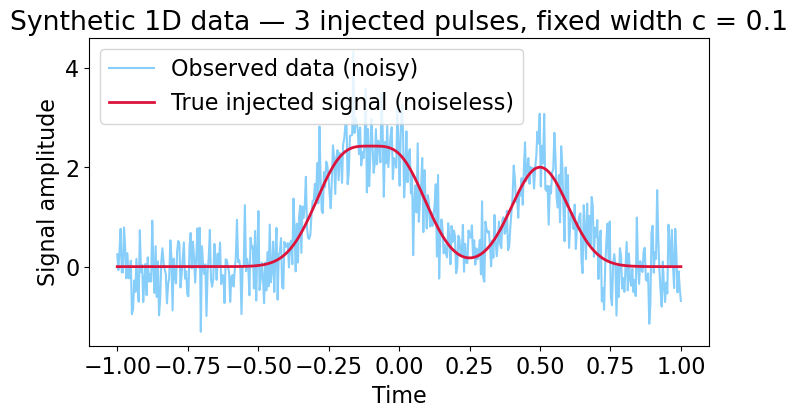

In [19]:
# SECTION 2 - TOY MODEL DEFINITION AND SYNTHETIC DATA GENERATION.

# 2.1 - Single pulse model

pulse_width_fixed = 0.1  # This is c in the Gaussian formula. FIXED for every pulse in the model (not sampled)

def single_gaussian_pulse(time_axis, pulse_amplitude, pulse_mean_position):
    """
    Evaluates ONE Gaussian pulse over the full time axis, given its amplitude
    and mean position. pulse_width_fixed is a closure over the module-level
    constant defined above — it is NOT a function argument, because it is
    identical (and fixed) for every pulse in the model.
    """
    pulse_values = pulse_amplitude * np.exp(
        -((time_axis - pulse_mean_position) ** 2) / (2 * pulse_width_fixed ** 2)
    )
    return pulse_values

# 2.2 - Combine an arbitrary number of pulses into one signal
"""
We need to do this because our model can contain multiple pulses simultaneously,
and we need their total sum. We start with an 'empty canvas' of zeros and use a
loop to calculate and add each pulse individually on top of the previous ones,
building the final, unified signal that will be compared to our actual observations.
"""

def combine_all_pulses(time_axis, list_of_pulse_parameter_pairs):
    """
    Sums up an arbitrary number of Gaussian pulses to build the full noiseless
    model signal. This is the function that must handle a VARIABLE number of
    pulses — exactly the quantity our trans-dimensional sampler is trying to infer.

    time_axis : np.ndarray
    list_of_pulse_parameter_pairs : iterable of (pulse_amplitude, pulse_mean_position) pairs
        Each element describes ONE active pulse.
    """
    # Example input: [[3.3, -0.2], [2.9, 0.3]]  (a list containing 2 pulses)

    # Creates the empty canvas. If time_axis has 500 points, this makes: [0.0, 0.0, ..., 0.0]
    combined_signal = np.zeros_like(time_axis)

    # 1st round of loop: takes [3.3, -0.2]
    # 2nd round of loop: takes [2.9, 0.3]
    for single_pulse_parameter_pair in list_of_pulse_parameter_pairs:

        # Unpacking the pair: e.g., pulse_amplitude gets 3.3, pulse_mean_position gets -0.2
        pulse_amplitude, pulse_mean_position = single_pulse_parameter_pair

        # Draws the pulse using 3.3 and -0.2, then adds it (+) to the existing combined_signal
        combined_signal += single_gaussian_pulse(time_axis, pulse_amplitude, pulse_mean_position)

    # After the loop finishes, returns the fully constructed waveform containing all pulses
    return combined_signal

# 2.3 Build the time axis
number_of_time_samples = 500
time_axis = np.linspace(-1, 1, number_of_time_samples)

# 2.4 - Define the TRUE injected pulses
true_injected_pulse_parameters = [
    [2, -0.2],
    [2,  0.0],
    [2, 0.5],
]

true_number_of_pulses = len(true_injected_pulse_parameters)
noiseless_injected_signal = combine_all_pulses(time_axis, true_injected_pulse_parameters)

# 2.5 Add Gaussian measurement noise to build the "observed data"

noise_standard_deviation = 0.5

"""
WHY WE DO THIS:
If we didn't have this check, re-running this cell would create NEW random noise every single time.
This means our 'observed_data' would change behind our back, ruining our analysis.
"""

# Check if the variable 'observed_data' already exists in the notebook's memory (locals).
if 'observed_data' not in locals():

    # 1. Create the random noise (the "snow" on the signal)
    measurement_noise = noise_standard_deviation * np.random.randn(number_of_time_samples)

    # 2. Add the noise to our perfect, noiseless model to create the final fake data
    observed_data = noiseless_injected_signal + measurement_noise

    # 3. Print a message so we know it was successfully created
    print(f"Generated observed_data ONCE with seed 42. "
          f"True number of pulses = {true_number_of_pulses}.")

else:
    # -- THIS RUNS IF YOU ACCIDENTALLY (OR INTENTIONALLY) RE-RUN THE CELL --
    print("observed_data already exists in memory — SKIPPING regeneration "
          "(delete the variable manually if you really want to resample noise).")

# 2.6 — Visualize: does the noisy data plausibly hide the injected signal?

plt.figure(figsize=(8, 4))
plt.plot(time_axis, observed_data, color="lightskyblue", label="Observed data (noisy)")
plt.plot(time_axis, noiseless_injected_signal, color="crimson", lw=2, label="True injected signal (noiseless)")
plt.xlabel("Time")
plt.ylabel("Signal amplitude")
plt.title(f"Synthetic 1D data — {true_number_of_pulses} injected pulses, "
          f"fixed width c = {pulse_width_fixed}")
plt.legend()
plt.show()

## Section 3 — Prior Bounds & Prior Distribution Object

### What a "prior" means here

For each **active** pulse, we need a prior probability density over its 2 parameters:

$$
\pi(A_i, \mu_i) = \pi(A_i)\,\pi(\mu_i)
$$

We assume these are **independent uniform distributions**:
- $A_i \sim \mathcal{U}(A_{\min}, A_{\max})$ — amplitude is equally likely anywhere in a plausible range.
- $\mu_i \sim \mathcal{U}(t_{\min}, t_{\max})$ — the pulse center can be anywhere within the observed time window.

### Why `ProbDistContainer` and not a raw dict?

Eryn's `EnsembleSampler` expects `priors` to be a dictionary mapping **branch name - `ProbDistContainer` object**, not a bare dictionary of `uniform_dist` objects. The `ProbDistContainer`:
- Wraps a `{parameter_index: distribution}` mapping into ONE object.
- Supplies `.rvs(size=...)` - draws random samples for **initializing walkers** (Section 6).
- Supplies `.logpdf(x)` - evaluates $\log \pi(x)$, which Eryn calls internally every time it needs the prior probability of a proposed point (both in-model Gaussian moves and RJ birth/death moves).

Without wrapping it this way, Eryn has no consistent interface to sample from or evaluate the prior for a variable, dictionary-based, multi-leaf parameter space.

### Parameter indexing convention

Inside the `"gauss"` branch, we use **integer keys** `0` and `1` to label which prior goes with which column of the `(..., ndim)` coordinate array:
- key `0` - amplitude (column 0)
- key `1` - mean position (column 1)

This ordering MUST exactly match the order you unpack parameters in `single_gaussian_pulse` (Section 2) and in the log-likelihood function (Section 4) — a mismatch here is one of the most common silent bugs in Eryn projects (e.g., accidentally treating amplitude values as time positions).

In [20]:
# SECTION 3 - PRIOR BOUNDS AND PRIOR DISTRIBUTION OBJECT

from eryn.prior import ProbDistContainer  # wraps per-parameter distributions into one object Eryn can call

# 3.1 - Define the numerical bounds of each prior

"""
Amplitude prior bounds:
chosen loosely around the injected amplitudes so the prior is broad enough to be
uninformative but still physically sensible
"""
amplitude_min = 0
amplitude_max = 5

"""
Mean-position prior bounds: pulses can only be centered WITHIN the observed time window.
Centering a pulse outside would be unidentifiable anyway.
"""
mean_position_min = time_axis.min()
mean_position_max = time_axis.max()

# 3.2 - Give this model-type a name

"""
Eryn organizes trans-dimensional models into named "branches". We only have ONE type of object
in our model, a Gaussian pulse, so we have one branch, named "gauss". If we later wanted to ALSO
infer, say, a noise-level parameter, that would become a second branch.
"""

branch_names = ["gauss"]

# 3.3 - Build the ProbDistContainer for the "gauss" branch

# Dictionary key convention: {column_index_in_coords_array: distribution}
#   key 0 -> pulse_amplitude        (must match unpacking order in Section 2 & 4!)
#   key 1 -> pulse_mean_position
gauss_branch_prior_dict = {
    # column 0: Amplitude
    # for example min = 0.0, can pick randomly 4.2
    0: uniform_dist(amplitude_min, amplitude_max),

    # column 1: Time position (Mean position)
    # for example, if min = -1 and max = 1 it can randomly pick -0.5
    1: uniform_dist(mean_position_min, mean_position_max)
}

# Eryn expects priors["gauss"] to be a ProbDistContainer OBJECT, not a raw dict.
priors = {
    # Here we take the dictionary above and wrap it in a "box"
    # in the exact format Eryn's algorithm expects to read.
    "gauss": ProbDistContainer(gauss_branch_prior_dict)
}

## Section 4 — Log-Likelihood Function & the Nested Sampling Hard Constraint

### The "true" physical likelihood

Assuming stationary, white, Gaussian measurement noise with known standard deviation $\sigma_n$, the likelihood of observing `observed_data` given a set of active pulses is:

$$
\log \mathcal{L}(\theta) = -\frac{1}{2}\sum_{j=1}^{N_t} \left(\frac{d_j - s(t_j;\theta)}{\sigma_n}\right)^2
$$

where $d_j$ is the observed data at time-sample $j$, and $s(t_j;\theta)$ is our model signal (sum of active pulses) from Section 2. This is the **standard Gaussian-noise log-likelihood** used throughout GW data analysis (up to an additive normalization constant that's irrelevant for both MCMC and Nested Sampling, since it cancels in likelihood *ratios* / doesn't change *where* the max is).

### Why Eryn needs TWO likelihood functions here, not one

1. **`true_gaussian_log_likelihood`** — computes the actual physical $\log\mathcal{L}(\theta)$ above. This is what we store for every dead/live point, and what ultimately builds the evidence integral in Section 10.

2. **`eryn_constrained_log_likelihood`** — the function we actually *hand to* Eryn's `EnsembleSampler`. This is where the **hard constraint** lives:

$$
\log\mathcal{L}_{\text{constrained}}(\theta) = 
\begin{cases}
0 & \text{if } \log\mathcal{L}(\theta) > \log\mathcal{L}_0 \\
-\infty & \text{otherwise}
\end{cases}
$$

### Why return `0`, not the real likelihood, when the constraint is satisfied?

This is the crux of how Nested Sampling's "constrained prior sampling" step works, and it trips up almost everyone the first time:

- Standard Nested Sampling requires drawing a **new live point uniformly from the prior, restricted to the region $\{\theta : \mathcal{L}(\theta) > \mathcal{L}_0\}$**.
- It does **NOT** want the MCMC to preferentially wander toward higher-likelihood points *inside* that region — that would bias the exploration and break the algorithm's core assumption (that within the constrained shell, all points are prior-weighted equally).
- If we returned the *actual* log-likelihood to Eryn, the RJ-MCMC's Metropolis-Hastings acceptance ratio would target $\pi(\theta)\mathcal{L}(\theta)$ restricted to the shell — i.e. it would still climb the likelihood surface *within* the allowed region.
- By instead returning a **flat, constant "likelihood"** (0 in log-space, i.e. likelihood = 1) whenever inside the constraint, and $-\infty$ outside it, the acceptance probability of a proposed move reduces to:

$$
\alpha = \min\!\left(1, \frac{\pi(\theta')}{\pi(\theta)} \cdot \mathbb{1}[\mathcal{L}(\theta') > \mathcal{L}_0]\right)
$$

  i.e. Eryn performs a **pure prior random walk, subject only to a boolean pass/fail gate** — exactly the "sample from the prior constrained to $\mathcal{L} > \mathcal{L}_0$" operation Nested Sampling requires. This matches the same trick your baseline `transnested.py` used (`log_like_fn_gauss_pulse_2`), and it is confirmed as the standard approach in the Nested Sampling literature you've been given (Skilling: *"we simply assume that sampling from within a likelihood constraint is possible... it might use MCMC over the prior, accepting only those points with greater likelihood"*).

### How does `current_logL0_threshold` get updated?

`current_logL0_threshold` is **not** a fixed constant — the outer Nested Sampling loop (Section 8) will *raise* it every iteration, as the worst live point is discarded. Because Eryn calls our log-likelihood function internally, deep inside `run_mcmc`, we can't just pass a new Python float as a function argument every iteration without re-building the sampler (expensive and messy). Instead, we use a **mutable one-element NumPy array** as a "pointer" — Eryn will always read whatever value is *currently* inside it, and our outer loop can update that value in-place, without needing to touch Eryn's internals at all.

### The hard-constraint check must use the strict inequality carefully

We reject (`-inf`) whenever $\log\mathcal{L}(\theta) \leq \log\mathcal{L}_0$ (not just `<`). This matches the Nested Sampling convention: the point that currently *defines* $\mathcal{L}_0$ is being replaced precisely because it is the worst live point — so a *new* candidate must be **strictly better**, never merely equal.

In [21]:
# SECTION 4 - LOG-LIKELIHOOD FUNCTION

# 4.1 - The true Gaussian-noise log-likelihood

def true_gaussian_log_likelihood(pulse_parameters_array, time_axis, observed_data, noise_standard_deviation):
    """
    We compute the physical log-likelihood of the data given a set of
    active pulses. This is the quantity we store for every live/dead point
    and later use to build the evidence integral.

    Parameters
    ----------
    pulse_parameters_array : np.ndarray, shape (n_active_pulses, pulse_ndim=2)
        Each row = [pulse_amplitude, pulse_mean_position] for ONE active pulse.
        n_active_pulses can be 0 (no signal -- pure noise hypothesis).
    time_axis : np.ndarray, shape (num_time_samples,)
    observed_data : np.ndarray, shape (num_time_samples,)
    noise_standard_deviation : float
    """

    model_signal = combine_all_pulses(time_axis, pulse_parameters_array)
    residual = (observed_data - model_signal) / noise_standard_deviation
    log_likelihood_value = -0.5 * np.sum(residual**2)

    return log_likelihood_value

# 4.2 - The mutable pointer holding the current NS threshold

"""
As the algorithm progresses, the minimum acceptable likelihood threshold
needs to continuously rise.

If we used a standard variable, the Eryn algorithm wouldn't realize
when we changed it. By using a single-element array, we create a "shared
memory space". When the main program raises the bar, Eryn sees it immediately
in its very next step, without needing to be restarted.
"""

# Just like in Section 3, we add a safety net. If we re-run
# this cell while the algorithm is working, we don't want to reset
# our progress.

if 'current_logL0_threshold' not in locals():
    # We start the threshold at -np.inf.
    # This means: For the very first step, accept any pulse, no matter how bad.
    current_logL0_threshold = np.array([-np.inf])

# 4.3 - The constrained log-likelihood Eryn will actually call

def eryn_constrained_log_likelihood(pulse_parameters_array, time_axis, observed_data, noise_standard_deviation):
    """
    Instead of scoring exactly how good a guess is, it only gives a pass or fail.
    Nested Sampling is like exploring a mountain by cutting it into flat slices
    starting from the bottom up. We want the algorithm to wander randomly anywhere
    on the current slice.

    If we returned the real score, the algorithm would try to climb directly to the peak.
    Returning 0.0 tricks the algorithm into walking flatly inside the allowed boundary
    without trying to climb.

    How it works:
    1. Calculate the real score.
    2. Compare it to our dynamic threshold.
    3. If it beats the threshold - pass.
    4. If it fails - reject - return -np.inf.
    """

    true_log_likelihood_value = true_gaussian_log_likelihood(
        pulse_parameters_array, time_axis, observed_data, noise_standard_deviation
    )

    if true_log_likelihood_value > current_logL0_threshold[0]:
        # Pass
        constrained_log_likelihood_value = 0.0

    else:
        # Fail
        constrained_log_likelihood_value = -np.inf

    return constrained_log_likelihood_value

# 4.4 Evaluate BOTH functions at the true injection

"""
Before we let the algorithm run for hours, we want to make sure our math
isn't broken. We do this by feeding our scoring functions the EXACT answers
to see what results they spit out.

If we feed in the perfect answers, the only difference between our guessed model
and the observed data is the random "snow" (noise) we added.

According to the math of Gaussian noise, this score should average out to
roughly (-0.5 * number of data points). If we have 500 time samples,
we expect a score hovering somewhere around -250.
"""
true_log_likelihood_at_injected_truth = true_gaussian_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis, observed_data, noise_standard_deviation
)

print(f"True log-likelihood at injected truth: {true_log_likelihood_at_injected_truth:.2f}  "
      f"(sanity range: should be roughly -0.5 * {number_of_time_samples} = {-0.5 * number_of_time_samples:.1f}, "
      f"give or take some natural random variance)")

"""
Right now, our threshold is sitting at -np.inf, since -250 or whatever
the true score is above is mathematically higher than -np.inf, this function
must pass the test and return 0.
"""
constrained_log_likelihood_at_injected_truth = eryn_constrained_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis, observed_data, noise_standard_deviation
)
print(f"Constrained log-likelihood at injected truth (expect 0.0 since threshold=-inf): "
      f"{constrained_log_likelihood_at_injected_truth}")

True log-likelihood at injected truth: -240.24  (sanity range: should be roughly -0.5 * 500 = -250.0, give or take some natural random variance)
Constrained log-likelihood at injected truth (expect 0.0 since threshold=-inf): 0.0


## Section 5 — Branch Structure: `nleaves_min` / `nleaves_max`

### What "branch structure" controls

This is where we tell Eryn the **rules of the trans-dimensional search space**:

- How many parameters does ONE pulse have? → `ndims_per_branch["gauss"] = 2` (pulse_amplitude, pulse_mean_position — this is where our `pulse_ndim = 2` simplification formally enters the Eryn API).
- What is the SMALLEST number of pulses Eryn's RJ-MCMC is allowed to explore? → `nleaves_min["gauss"]`
- What is the LARGEST number of pulses the model is allowed to have? → `nleaves_max["gauss"]`

### Why `nleaves_min["gauss"] = 1` (NOT 0) — and how k=0 is still handled

Physically, we still want the sampler to be able to conclude **"there is no signal at all — this is pure noise"** — that's what makes this a genuine model-selection problem rather than a "how many pulses, at least 1" search.

However, we do **not** implement this by setting `nleaves_min["gauss"] = 0` inside Eryn's RJ-MCMC. There is a known Eryn internal bug: a walker with **zero active leaves in every branch** returns a `NaN` log-likelihood, which corrupts the whole ensemble. To sidestep this:

- `nleaves_min["gauss"] = 1`: Eryn's RJ-MCMC only ever explores $k \geq 1$.
- The $k=0$ ("no signal") hypothesis is handled **analytically, outside Eryn entirely**: with zero free parameters, evidence = likelihood, computed once as `log_evidence_no_signal_model`.
- In Section 10, the two evidences are combined via `log_add_exp(log_evidence_signal_model, log_evidence_no_signal_model)` to recover the full $P(k=0 \mid \text{data})$ vs. $P(k \geq 1 \mid \text{data})$ comparison — so the model-selection question is still answered in full, just split across two computational paths instead of one unified RJ-MCMC run.

**Bias check**: this split does NOT bias the comparison, provided (a) the $k \geq 1$ evidence from Eryn is a correct estimate of $Z_{k\geq1} = \int P(k\geq 1)\, P(\theta\mid k)\, \mathcal{L}(\theta)\, d\theta\, dk$ restricted to $k\geq1$, and (b) the discrete prior mass split between $k=0$ and $k\geq1$ is applied consistently when combining them (see Section 10.4). It is a computational workaround for the Eryn bug, not a modeling assumption.

### Choosing `nleaves_max`

`nleaves_max["gauss"]` must be large enough that the TRUE number of pulses (3, in our injection) sits comfortably inside the allowed range — otherwise the sampler *cannot* recover the truth even in principle. But it can't be absurdly large either:
- Every leaf slot (active or not) still occupies memory in the padded `(..., nleaves_max, ndim)` arrays (see the Eryn cheat sheet: fixed-size padding).
- A larger `nleaves_max` also enlarges the *discrete* part of the trans-dimensional prior (a uniform prior over $k \in \{1, ..., n_{\max}\}$ spreads the same total prior probability across more values), which can slow down convergence of the model-order posterior.

We'll use `nleaves_max["gauss"] = 6` — double the true injected count of 3 — giving comfortable headroom without being wasteful.

### `ndims_per_branch` and `nleaves_max` must be DICTIONARIES

Per the Eryn API rules established for this project: since we could in principle have *multiple* branches (multiple types of objects in the model), Eryn always expects these as `{branch_name: value}` dictionaries, even when — like here — there's only one branch. Passing a bare integer instead of `{"gauss": 2}` is a common shape-mismatch bug.

In [22]:
# SECTION 5 - BRANCH STRUCTURE SETUP

# 5.1 - Per-pulse dimensionality

"""
This is the formal Eryn-API expression of our pulse_ndim = 2 simplification:
each "gauss" leaf (pulse) has exactly 2 free parameters (pulse_amplitude, pulse_mean_position)
"""

pulse_ndim = 2
ndims_per_branch = {"gauss": pulse_ndim}

# 5.2 - Minimum and maximum number of active pulses allowed

# nleaves_min must be 1 for Eryn's RJ-MCMC. The k=0 ("no signal") hypothesis is NOT
# abandoned -- it is handled analytically instead (see log_evidence_no_signal_model
# below), because a zero-parameter model needs no integration. This also sidesteps
# an Eryn internal bug where a walker with zero active leaves in every branch
# gets a NaN log-likelihood.
nleaves_min = {"gauss": 1}

# nleaves_max = 6 is double the true injected count (3 pulses), giving
# headroom to recover the truth while keeping the padded arrays a manageable size
nleaves_max = {"gauss": 6}

# The analytic evidence of the no-signal model: with zero free parameters,
# evidence == likelihood. Computed once, used in Section 10's Bayes factor.
log_evidence_no_signal_model = true_gaussian_log_likelihood(
    np.empty((0, pulse_ndim)), time_axis, observed_data, noise_standard_deviation
)
print(f"Analytic log-evidence of the k=0 (no signal) model: {log_evidence_no_signal_model:.4f}")

# 5.3 - Catch shape/logic mistakes early

assert isinstance(ndims_per_branch, dict), "ndims_per_branch must be a dict, e.g. {'gauss': 2} -- Eryn requirement."
assert isinstance(nleaves_max, dict), "nleaves_max must be a dict -- Eryn requirement."
assert nleaves_min["gauss"] <= nleaves_max["gauss"], \
    "nleaves_min cannot exceed nleaves_max -- the allowed range would be empty."
assert nleaves_max["gauss"] >= true_number_of_pulses, \
    (f"nleaves_max={nleaves_max['gauss']} is smaller than the true injected "
     f"number of pulses ({true_number_of_pulses}) -- the sampler could NEVER "
     f"recover the truth. Increase nleaves_max.")

print(f"Branch 'gauss': ndim={ndims_per_branch['gauss']} (pulse_amplitude, pulse_mean_position), "
      f"nleaves range = [{nleaves_min['gauss']}, {nleaves_max['gauss']}], "
      f"true injected count = {true_number_of_pulses}.")

Analytic log-evidence of the k=0 (no signal) model: -1608.9564
Branch 'gauss': ndim=2 (pulse_amplitude, pulse_mean_position), nleaves range = [1, 6], true injected count = 3.


## Section 6 — Initializing Live Points: Coordinates & `inds` Masks

### What we're building here

In our architecture, the **live points of the Nested Sampling algorithm play the role that "walkers" normally play in plain Eryn/emcee usage.** We need to build TWO padded arrays per branch, per the shapes fixed in the Eryn cheat sheet:

- `live_point_coordinates["gauss"]`, shape `(ntemps, nlive, nleaves_max, ndim)` — the actual $(A_i, \mu_i)$ values for every possible leaf slot, active or not.
- `live_point_active_leaf_mask["gauss"]`, shape `(ntemps, nlive, nleaves_max)`, **boolean** — `True` means "this leaf slot currently represents a real, active pulse"; `False` means "this slot is padding, ignored by the likelihood and prior."

### The critical Bayesian point: initialize live points from the FULL prior

A tempting shortcut (used for testing in the provided baseline `transnested.py`) is to *seed* every live point near the true injected parameters. **We deliberately do NOT do that here.** Proper Nested Sampling requires that the *initial* live point population be drawn **i.i.d. from the joint prior** — which, in our trans-dimensional setting, means:

1. First, draw the **number of active pulses** for each live point *uniformly* from $\{n_{\min}, ..., n_{\max}\}$ (this is the discrete part of the trans-dimensional prior). Recall from Section 5: $n_{\min} = 1$ here, since $k=0$ is handled analytically, outside this population entirely.
2. Then, for however many pulses are active, draw their $(A_i, \mu_i)$ from `priors["gauss"]` (the continuous part).

If instead we seed near the truth, we get a "warm start" that may converge faster, but it silently **injects information about the answer into the sampler's exploration**, invalidating the resulting evidence integral, and it hides bugs in your RJ-birth/death moves that would otherwise be caught by needing to genuinely explore all model orders from scratch.

### Why fill INACTIVE slots too (not `NaN`)?

Even though inactive leaf values are ignored by our likelihood/prior functions (Section 4 receives only the active-leaf sub-array), Eryn's internal move proposals (in particular RJ "birth" moves, which activate a currently-inactive leaf) may read the existing padding value as a starting point before overwriting it with a freshly-drawn prior sample. Leaving `NaN` there is asking for silent propagation of `NaN` through downstream arithmetic. We fill every slot — active or not — with a valid prior draw.

### Safety check

Because this involves random draws that seed the ENTIRE nested sampling run, we guard it so re-running the cell doesn't silently reshuffle your live point population mid-analysis.

In [23]:
# SECTION 6 - INITIALIZING LIVE POINTS (COORDINATES + inds MASKS)

# 6.1 - Population sizes

number_of_temperatures = 1  # single temperature - no parallel tempering for this toy problem

"""
Rule of thumb for scaling the number of Nested Sampling live points:
roughly 25x the per-pulse dimensionality is a reasonable, if approximate,
starting point. This is a tunable knob: more live points = better evidence
precision, slower runtime.
"""
number_of_live_points = 25 * pulse_ndim

# 6.2 - Only initialize once

if 'live_point_coordinates' not in locals():

    # Step 1: Draw the NUMBER of active pulses per live point.
    # low = nleaves_min["gauss"] = 1 (NOT 0): recall from Section 5 that k=0
    # is handled analytically, outside Eryn's RJ-MCMC entirely, so every live
    # point here must start with AT LEAST one active pulse.
    number_of_active_pulses_per_live_point = np.random.randint(
        low=nleaves_min["gauss"],                     # 1 (the minimum active pulses Eryn's RJ-MCMC explores)
        high=nleaves_max["gauss"] + 1,                 # 6 + 1 = 7 (picks a random number from 1 to 6)
        size=(number_of_temperatures, number_of_live_points)  # Example: (1, 50). We roll the dice 50 times, once for each explorer
    )

    # Step 2: Allocate the padded coordinate array
    """
    For example: we create a giant empty spreadsheet of size (1, 50, 6, 2).
    1 temp, 50 explorers, 6 maximum possible slots for pulses, 2 features (amplitude, mean position).
    Every explorer gets exactly 6 slots, even if they only need 2.
    """
    live_point_coordinates = {
        "gauss": np.empty((number_of_temperatures, number_of_live_points, nleaves_max["gauss"], ndims_per_branch["gauss"]))
    }

    # Step 3: Allocate the boolean active-leaf mask
    # Example: we create a giant spreadsheet of "on/off switches" of size (1, 50, 6).
    # We start by setting ALL switches to False (off).
    live_point_active_leaf_mask = {
        "gauss": np.zeros((number_of_temperatures, number_of_live_points, nleaves_max["gauss"]), dtype=bool)
    }

    # Step 4: Fill every slot (active or not) with a valid prior draw, and mark the first 'k' slots
    # per live point as active
    for temperature_index in range(number_of_temperatures):
        for live_point_index in range(number_of_live_points):

            # Example: we check what Explorer 1 rolled in Step 1. Let's say they rolled a "2"
            active_pulse_count_this_live_point = number_of_active_pulses_per_live_point[temperature_index, live_point_index]

            # Example: we draw 6 completely random pulses from our prior box (Section 3)
            prior_draws_for_all_slots = priors["gauss"].rvs(size=(nleaves_max["gauss"],))

            # Example: we put all 6 random pulses into Explorer 1's slots
            live_point_coordinates["gauss"][temperature_index, live_point_index] = prior_draws_for_all_slots

            # Example: since Explorer 1 only needs 2 pulses, we turn the switch to True (on)
            # ONLY for the first 2 slots. The other 4 slots remain False (off).
            # The algorithm will now only use the first 2 slots and ignore the rest.
            live_point_active_leaf_mask["gauss"][temperature_index, live_point_index, :active_pulse_count_this_live_point] = True

    print(f"Initialized {number_of_live_points} live points from the FULL prior (no warm-starting at the truth).")
    print(f"Active-pulse-count distribution across live points: "
          f"{np.bincount(number_of_active_pulses_per_live_point.flatten(), minlength=nleaves_max['gauss']+1)}")

else:
    print("live_point_coordinates already exists -- SKIPPING re-initialization "
          "(delete both live_point_coordinates and live_point_active_leaf_mask "
          "manually if you really want to reseed the live point population).")

live_point_coordinates already exists -- SKIPPING re-initialization (delete both live_point_coordinates and live_point_active_leaf_mask manually if you really want to reseed the live point population).


## Section 7 — Building the Eryn `EnsembleSampler`

### The key architectural point: `nwalkers` (Eryn) ≠ `live_points` (our Nested Sampling)

This is the single most confusing part of this hybrid architecture, so let's be very explicit:

*   **`live_points`** (Section 6) is **our own bookkeeping quantity** — the size of the population of Nested Sampling live points that WE maintain in plain NumPy arrays (`live_point_coordinates`, `live_point_active_leaf_mask`). Eryn knows nothing about this.
*   **`nwalkers`** is an **Eryn-internal concept**: how many parallel MCMC chains Eryn's `EnsembleSampler` evolves *inside a single call to `run_mcmc`*.

In our design we set **`nwalkers = 1`**. Here's why: at each Nested Sampling iteration (Section 8), the outer loop will:
1.  Discard the current worst live point.
2.  Pick ONE surviving live point at random as a starting position `x0`.
3.  Hand `x0` to Eryn as a **single walker**, and ask it to take a short constrained random walk (`mcmc_steps` steps) via `run_mcmc`.
4.  Read off wherever that one walker ends up as the newly-generated replacement live point.

So Eryn's `EnsembleSampler` object is built **once**, up front (this section), and then **reused** every Nested Sampling iteration in Section 8 — we just feed it a different single-walker starting `State` each time, driven by our custom loop, rather than letting Eryn run one giant continuous chain of its own.

### Why `GaussianMove` for in-model steps

Between RJ birth/death jumps (which change the number of active pulses), Eryn also needs a proposal to explore **within** a fixed dimensionality — e.g., refining amplitude/mean for a pulse that's already active. `GaussianMove(cov)` proposes small random-walk steps drawn from $\mathcal{N}(0, \Sigma)$ around the current position, where $\Sigma$ (`cov`) is a diagonal covariance matrix, one entry per parameter (amplitude, mean).

**Why keep `cov` small?** A large step size means most in-model proposals will land outside the current hard-constraint shell $\{\theta : \mathcal{L}(\theta) > \mathcal{L}_0\}$ and simply get rejected (`-np.inf`) — wasting the `mcmc_steps` budget. A small step size mixes more slowly but stays "on the shell" more often. This is a real efficiency/correctness trade-off you'll likely need to retune once you see acceptance rates in Section 9.

### `args` — passing fixed data through to the likelihood

`args=[time_axis, observed_data, noise_standard_deviation]` are passed straight through to every call of `eryn_constrained_log_likelihood(pulse_parameters_array, *args)`. Notice `current_logL0_threshold` is **NOT** in `args` — it doesn't need to be, since it's a mutable array captured by closure (Section 4.2); Eryn always sees its live value without us needing to re-pass it.

### `rj_moves=True`

This single flag is what activates Eryn's **reversible-jump birth/death proposals** — without it, Eryn would only ever explore within the *initial* number of active leaves per walker, defeating the entire purpose of the trans-dimensional search.

In [24]:
# SECTION 7 - BUILDING THE EnsembleSampler OBJECT

from eryn.moves import GaussianMove
from eryn.ensemble import EnsembleSampler

# 7.1 - In-model proposal (Gaussian random walk)

"""
One proposal step-size scale per parameter (pulse_amplitude, pulse_mean_position), kept small
and diagonal so that proposals are more likely to stay inside the current hard-constraint shell.
"""

gaussian_move_step_size_scale = 1e-3

gaussian_move_covariance = {
    "gauss": np.diag(np.ones(ndims_per_branch["gauss"])) * gaussian_move_step_size_scale
}

in_model_proposal_move = GaussianMove(gaussian_move_covariance)

# 7.2 - Number of Eryn-internal walkers (NOT the same as live_points)

"""
number_of_walkers = 1: Eryn evolves exactly ONE walker per run_mcmc call. Our custom outer
Nested Sampling loop is what supplies the population structure (live_points), by repeatedly
calling run_mcmc with a freshly chosen single starting point.
"""
number_of_walkers = 1

# 7.3 - Build the EnsembleSampler once

# nleaves_min changed earlier, so an already-built ensemble object would be stale -- force a rebuild
if 'ensemble' in locals():
    del ensemble

"""
Building this is cheap, but re-running the cell would silently discard any custom state attached
to 'ensemble'. Guard it so accidental re-execution doesn't surprise us.
"""
if 'ensemble' not in locals():
    ensemble = EnsembleSampler(
        number_of_walkers,
        ndims_per_branch,                           # dict: {"gauss": 2}  (pulse_amplitude, pulse_mean_position)
        eryn_constrained_log_likelihood,            # the HARD-CONSTRAINED likelihood from Section 4
        priors,                                     # dict: {"gauss": ProbDistContainer(...)} from Section 3
        args=[time_axis, observed_data, noise_standard_deviation],  # fixed data, passed to the likelihood every call
        tempering_kwargs=dict(ntemps=number_of_temperatures),  # number_of_temperatures = 1, no parallel tempering for this toy problem
        nbranches=len(branch_names),                # 1 branch: "gauss"
        branch_names=branch_names,                  # ["gauss"]
        nleaves_max=nleaves_max,                    # dict: {"gauss": 6}
        nleaves_min=nleaves_min,                    # dict: {"gauss": 1}  -- allows the "no signal" hypothesis (handled analytically now)
        moves=in_model_proposal_move,               # GaussianMove for within-dimension steps
        rj_moves=True,                              # enables reversible-jump birth/death proposals
    )
    print("EnsembleSampler built successfully.")
else:
    print("ensemble already exists -- SKIPPING rebuild "
          "(delete the `ensemble` variable manually if you need to reconfigure it).")

# 7.4 - Evaluate prior + constrained likelihood at ONE live point

"""
We slice the first live point (index 0:1) from our arrays.
This confirms the ensemble object can talk to our functions without shape errors,
respecting the number_of_walkers=1 rule.
"""

test_coords = {"gauss": live_point_coordinates["gauss"][:, 0:1, :, :]}
test_inds = {"gauss": live_point_active_leaf_mask["gauss"][:, 0:1, :]}

check_log_prior = ensemble.compute_log_prior(
    test_coords, inds=test_inds
)

check_log_like = ensemble.compute_log_like(
    test_coords, inds=test_inds, logp=check_log_prior
)[0]

print(f"log_prior shape: {check_log_prior.shape} (expect (ntemps={number_of_temperatures}, nlive=1))")
print(f"log_like  shape: {check_log_like.shape} (expect (ntemps={number_of_temperatures}, nlive=1))")
print(f"log_like values (all should be 0.0 or -inf, since current_logL0_threshold = {current_logL0_threshold[0]}):")
print(check_log_like.squeeze())

EnsembleSampler built successfully.
log_prior shape: (1, 1) (expect (ntemps=1, nlive=1))
log_like  shape: (1, 1) (expect (ntemps=1, nlive=1))
log_like values (all should be 0.0 or -inf, since current_logL0_threshold = -9978.441530495766):
0.0


## Section 8 — Nested Sampling Logic Layer: Worst-Point Replacement & Dead-Point Storage

This is the heart of the whole notebook — the part that actually turns "an RJ-MCMC engine" into "a Trans-dimensional Nested Sampler." Read this slowly.

### 8.1 — What "one Nested Sampling iteration" means

Standard Nested Sampling (Skilling 2006), at every iteration:

1. Among the current $N_{\text{live}}$ live points, **find the one with the LOWEST likelihood**, $\mathcal{L}_{\text{worst}}$.
2. **Move it to the "dead points" archive** — it has now told us everything it can; it represents the current *innermost* shrinking prior-volume shell.
3. **Draw a replacement live point**, uniformly from the prior, subject to the constraint $\mathcal{L}(\theta) > \mathcal{L}_{\text{worst}}$ — this is exactly what `eryn_constrained_log_likelihood` + a short RJ-MCMC walk (Sections 4 & 7) accomplish for us.
4. **Shrink the estimated enclosed prior volume**: on average, each iteration multiplies the remaining prior volume $X$ by a factor $\approx \frac{N_{\text{live}}}{N_{\text{live}}+1}$, so
$$
\log X_i \approx -\frac{i}{N_{\text{live}}}
$$
after $i$ iterations. We don't need to track $X$ ourselves during the loop — **`anesthetic` will reconstruct $X$ statistically from the sequence of dead points** in Section 10 — but it's worth internalizing *why* the loop works: every iteration we're peeling off the point at the current innermost shell and asking "give me a new point, somewhere inside a slightly smaller shell."

### 8.2 — Why we need `live_point_true_log_likelihood` as a SEPARATE array

The `eryn_constrained_log_likelihood` from Section 4 only ever returns `0.0` or `-np.inf` — it deliberately throws away the actual likelihood VALUE (that's the point of the hard-constraint trick). But the **outer Nested Sampling loop absolutely needs the true, continuous $\log\mathcal{L}$ values** to know *which* live point is worst and *what* threshold to enforce next. So we maintain our own bookkeeping array, `live_point_true_log_likelihood`, computed via `true_gaussian_log_likelihood` (Section 4.1) directly — completely separate from what we feed Eryn.

### 8.3 — Why we also need `live_point_birth_log_likelihood`

For `anesthetic`'s `NestedSamples` (used in Section 10) to correctly reconstruct the evidence and its uncertainty, every dead point needs to know **the constraint threshold that was active when it was BORN** (i.e., $\mathcal{L}_0$ at the moment this point *replaced* some earlier worst point) — not just its own final $\log\mathcal{L}$. This is what lets `anesthetic` handle live points that are born at *different* stages of the run (relevant when contours cross, or plateaus occur — see the Skilling nested-sampling theory in your reference PDFs). Points from the **initial** prior draw (Section 6) were technically "born" under no constraint at all, so we set their birth threshold to $-\infty$.

### 8.4 — Why pick a RANDOM survivor as the RJ-MCMC seed (not, say, the best point)

Seeding the replacement search from a **uniformly random surviving live point** (rather than always the current best point) is what keeps the replacement approximately prior-distributed within the constrained shell, rather than biasing it towards a specific region of parameter space. This mirrors exactly what the baseline `transnested.py` does (`rand_lp = np.random.choice(len(x))`).

### 8.5 — The correctness assertion you should never skip

After the short RJ-MCMC walk under the hard constraint, the **new point's true log-likelihood must be strictly greater than the threshold we just enforced.** If it is not, something is badly wrong — either the constraint logic in Section 4 has a bug, or `mcmc_steps` was too short and the walker never actually escaped the immediately-preceding dead point (which can happen with the RNG returning the SAME point if all proposed moves got rejected). We assert this explicitly rather than silently trusting Eryn.

In [25]:
# SECTION 8 - NESTED SAMPLING LOGIC LAYER

from eryn.state import State

# 8.1 - Live-point bookkeeping arrays

if 'live_point_true_log_likelihood' not in locals():
    live_point_true_log_likelihood = np.empty(number_of_live_points)

    for live_point_index in range(number_of_live_points):
        active_mask_this_point = live_point_active_leaf_mask["gauss"][0, live_point_index]
        active_parameters_this_point = live_point_coordinates["gauss"][0, live_point_index][active_mask_this_point]
        live_point_true_log_likelihood[live_point_index] = true_gaussian_log_likelihood(
            active_parameters_this_point, time_axis, observed_data, noise_standard_deviation
        )

    live_point_birth_log_likelihood = np.full(number_of_live_points, -np.inf)

    print(f"Initialized true log-likelihoods for {number_of_live_points} live points.")
    print(f"  min logL = {live_point_true_log_likelihood.min():.3f}, "
          f"max logL = {live_point_true_log_likelihood.max():.3f}")
else:
    print("live_point_true_log_likelihood already exists -- SKIPPING re-initialization.")


# 8.2 - Dead-point archive

if 'dead_point_coordinates' not in locals():
    dead_point_coordinates = np.empty((0, nleaves_max["gauss"], ndims_per_branch["gauss"]))
    dead_point_active_leaf_mask = np.empty((0, nleaves_max["gauss"]), dtype=bool)
    dead_point_log_likelihood = np.empty(0)
    dead_point_birth_log_likelihood = np.empty(0)
    print("Initialized empty dead-point archive.")
else:
    print(f"dead_point_coordinates already exists ({dead_point_coordinates.shape[0]} dead points so far) "
          f"-- SKIPPING re-initialization.")


# 8.3 - Sanitize inactive leaf coordinates

# Eryn's RJ death moves can leave NaN in a leaf slot once it's deactivated.
# Those NaNs propagate into later evaluations even though the slot is masked
# out by `inds`, so we always refill inactive slots with valid prior draws.

def sanitize_inactive_leaf_coordinates(coordinates_array, active_mask_array):
    sanitized_coordinates = coordinates_array.copy()
    inactive_slot_indices = np.where(~active_mask_array)[0]
    if len(inactive_slot_indices) > 0:
        sanitized_coordinates[inactive_slot_indices] = priors["gauss"].rvs(
            size=(len(inactive_slot_indices),)
        )
    return sanitized_coordinates


# 8.4 - Enforce the k >= 1 invariant that Eryn requires

# Since nleaves_min["gauss"] = 1 (Section 5), no point handed to Eryn may
# have zero active leaves. If a point is ever found with k=0, we repair it
# by activating one leaf, filled with a fresh prior draw, so it becomes a
# legitimate k=1 point rather than a corrupted one.

def enforce_minimum_one_active_leaf(coordinates_array, active_mask_array):
    """
    Returns (coordinates, mask) guaranteed to have at least one active leaf.
    If already k>=1, returns the inputs unchanged.
    """
    if active_mask_array.sum() >= 1:
        return coordinates_array, active_mask_array

    repaired_mask = active_mask_array.copy()
    repaired_coordinates = coordinates_array.copy()
    repaired_mask[0] = True
    repaired_coordinates[0] = priors["gauss"].rvs(size=(1,))[0]
    return repaired_coordinates, repaired_mask


# 8.5 - Hand-computed log_prior / constrained log_like for ONE point

# We compute these ourselves rather than via ensemble.compute_log_prior /
# compute_log_like, which mishandle low-leaf-count edge cases.
#
# NOTE: compute_seed_log_prior_and_log_like below is not currently called
# anywhere in this section -- perform_one_nested_sampling_iteration computes
# the seed's log-prior inline instead and hardcodes log_like=0.0 (the seed is
# guaranteed inside the current shell by construction, so no constrained
# likelihood evaluation is needed for it). Kept here in case Section 9 needs
# a single-call convenience wrapper; remove if it stays unused.

def compute_log_prior_for_one_point(active_parameters_array):
    n_active = active_parameters_array.shape[0]
    if n_active == 0:
        return 0.0   # log(1): empty product of probabilities
    return float(np.sum(priors["gauss"].logpdf(active_parameters_array)))


def compute_seed_log_prior_and_log_like(active_parameters_array):
    log_prior_value = compute_log_prior_for_one_point(active_parameters_array)
    true_logL = true_gaussian_log_likelihood(
        active_parameters_array, time_axis, observed_data, noise_standard_deviation
    )
    # Same hard-constraint rule as eryn_constrained_log_likelihood (Section 4).
    # NaN-safe: a NaN true_logL fails the ">" comparison and yields -inf.
    constrained_log_like_value = 0.0 if true_logL > current_logL0_threshold[0] else -np.inf
    return log_prior_value, constrained_log_like_value


# 8.6 - One Nested Sampling iteration

def are_active_parameters_within_prior_bounds(active_parameters_array):
    """Checks every active leaf lies inside the uniform prior support."""
    if active_parameters_array.shape[0] == 0:
        return True
    amplitude_ok = np.all((active_parameters_array[:, 0] >= amplitude_min) &
                          (active_parameters_array[:, 0] <= amplitude_max))
    mean_ok = np.all((active_parameters_array[:, 1] >= mean_position_min) &
                     (active_parameters_array[:, 1] <= mean_position_max))
    return bool(amplitude_ok and mean_ok)


def evaluate_live_point_validity(coordinates_array, active_mask_array):
    """
    Returns (is_usable, true_logL). A point is usable as an RJ-MCMC seed only if
    it has k>=1, finite in-bounds ACTIVE coordinates, and satisfies the current
    hard constraint. We check the ACTIVE coordinates here, not just the inactive
    padding, since a corrupted active leaf would otherwise permanently disable
    that live point as a seed.
    """
    active_parameters = coordinates_array[active_mask_array]

    if active_parameters.shape[0] < 1:
        return False, -np.inf
    if not np.all(np.isfinite(active_parameters)):
        return False, -np.inf
    if not are_active_parameters_within_prior_bounds(active_parameters):
        return False, -np.inf

    true_logL = true_gaussian_log_likelihood(
        active_parameters, time_axis, observed_data, noise_standard_deviation
    )
    if not np.isfinite(true_logL):
        return False, -np.inf

    return bool(true_logL > current_logL0_threshold[0]), true_logL


# Counters so degraded behaviour is VISIBLE rather than silent.
if 'replacement_by_eryn_count' not in locals():
    replacement_by_eryn_count = 0
    replacement_by_clone_fallback_count = 0


def perform_one_nested_sampling_iteration(mcmc_steps_per_replacement):
    global live_point_coordinates, live_point_active_leaf_mask
    global live_point_true_log_likelihood, live_point_birth_log_likelihood
    global dead_point_coordinates, dead_point_active_leaf_mask
    global dead_point_log_likelihood, dead_point_birth_log_likelihood
    global current_logL0_threshold
    global replacement_by_eryn_count, replacement_by_clone_fallback_count

    # Step 1: find the worst live point
    worst_point_index = int(np.argmin(live_point_true_log_likelihood))
    worst_point_logL = live_point_true_log_likelihood[worst_point_index]

    # Step 2: archive it in the dead-point record
    dead_point_coordinates = np.concatenate(
        [dead_point_coordinates,
         live_point_coordinates["gauss"][0, worst_point_index][None, :, :]], axis=0)
    dead_point_active_leaf_mask = np.concatenate(
        [dead_point_active_leaf_mask,
         live_point_active_leaf_mask["gauss"][0, worst_point_index][None, :]], axis=0)
    dead_point_log_likelihood = np.append(dead_point_log_likelihood, worst_point_logL)
    dead_point_birth_log_likelihood = np.append(
        dead_point_birth_log_likelihood, live_point_birth_log_likelihood[worst_point_index])

    # Step 3: raise the hard constraint to the newly discarded likelihood
    current_logL0_threshold[0] = worst_point_logL

    # Step 4: collect every USABLE survivor to seed the replacement search
    usable_seed_indices = []
    for candidate_index in range(number_of_live_points):
        if candidate_index == worst_point_index:
            continue
        is_usable, candidate_logL = evaluate_live_point_validity(
            live_point_coordinates["gauss"][0, candidate_index],
            live_point_active_leaf_mask["gauss"][0, candidate_index])
        if is_usable:
            # Keep the bookkeeping array in sync -- drift between stored logL
            # and actual coordinates would silently poison the population.
            live_point_true_log_likelihood[candidate_index] = candidate_logL
            usable_seed_indices.append(candidate_index)

    if len(usable_seed_indices) == 0:
        raise RuntimeError(
            f"No usable live point remains at threshold logL={worst_point_logL:.4f}. "
            f"The live population has collapsed -- this is a genuine sampler failure, "
            f"not a transient one.")

    np.random.shuffle(usable_seed_indices)

    # Steps 5-7: try each usable seed until one yields a valid replacement
    for seed_index in usable_seed_indices:

        seed_coords_clean = sanitize_inactive_leaf_coordinates(
            live_point_coordinates["gauss"][0, seed_index],
            live_point_active_leaf_mask["gauss"][0, seed_index])
        seed_mask_clean = live_point_active_leaf_mask["gauss"][0, seed_index].copy()
        live_point_coordinates["gauss"][0, seed_index] = seed_coords_clean

        seed_log_prior_value = compute_log_prior_for_one_point(seed_coords_clean[seed_mask_clean])
        if not np.isfinite(seed_log_prior_value):
            continue

        starting_state = State(
            {"gauss": seed_coords_clean[None, None, :, :].copy()},
            inds={"gauss": seed_mask_clean[None, None, :].copy()},
            log_like=np.array([[0.0]]),                 # seed is inside the shell by construction
            log_prior=np.array([[seed_log_prior_value]]))

        try:
            final_state = ensemble.run_mcmc(
                starting_state, mcmc_steps_per_replacement, progress=False)
        except ValueError:
            continue   # Eryn produced a non-finite internal state, try another seed

        replacement_active_mask = final_state.branches["gauss"].inds[0, 0].copy()
        replacement_coordinates = sanitize_inactive_leaf_coordinates(
            final_state.branches["gauss"].coords[0, 0], replacement_active_mask)

        is_usable, replacement_true_logL = evaluate_live_point_validity(
            replacement_coordinates, replacement_active_mask)
        if not is_usable:
            continue   # walker never escaped the shell, or landed somewhere invalid

        # --- 8.5 correctness assertion: never skip this ---
        # is_usable already encodes replacement_true_logL > worst_point_logL, but we
        # assert it explicitly and separately here: this is the one invariant that
        # defines a VALID Nested Sampling step. If this ever fires, the bug is in
        # evaluate_live_point_validity's threshold check or in current_logL0_threshold
        # bookkeeping above -- trust nothing silently, not even our own helper functions.
        assert replacement_true_logL > worst_point_logL, (
            f"NESTED SAMPLING CORRECTNESS VIOLATION: replacement logL "
            f"({replacement_true_logL:.6f}) does not strictly exceed the discarded "
            f"threshold ({worst_point_logL:.6f}).")

        live_point_coordinates["gauss"][0, worst_point_index] = replacement_coordinates
        live_point_active_leaf_mask["gauss"][0, worst_point_index] = replacement_active_mask
        live_point_true_log_likelihood[worst_point_index] = replacement_true_logL
        live_point_birth_log_likelihood[worst_point_index] = worst_point_logL

        replacement_by_eryn_count += 1
        return worst_point_logL, replacement_true_logL

    # Fallback: clone a usable survivor
    #
    # It satisfies logL > threshold by construction, so the run continues.
    # This is a degraded move: the clone is perfectly correlated with its parent,
    # which under-estimates the compression and biases logZ. We count it so the
    # damage is measurable rather than invisible.
    clone_index = usable_seed_indices[0]
    clone_logL = live_point_true_log_likelihood[clone_index]

    # --- 8.5 correctness assertion, fallback path too ---
    assert clone_logL > worst_point_logL, (
        f"NESTED SAMPLING CORRECTNESS VIOLATION (clone fallback): clone logL "
        f"({clone_logL:.6f}) does not strictly exceed the discarded threshold "
        f"({worst_point_logL:.6f}).")

    live_point_coordinates["gauss"][0, worst_point_index] = \
        live_point_coordinates["gauss"][0, clone_index].copy()
    live_point_active_leaf_mask["gauss"][0, worst_point_index] = \
        live_point_active_leaf_mask["gauss"][0, clone_index].copy()
    live_point_true_log_likelihood[worst_point_index] = clone_logL
    live_point_birth_log_likelihood[worst_point_index] = worst_point_logL

    replacement_by_clone_fallback_count += 1
    return worst_point_logL, clone_logL


# 8.7 - One-time repair of the current live population

# Fixes both NaN padding and any k=0 points that may have slipped through
# initialization, so the population fully satisfies nleaves_min=1 before
# we start running iterations on it.

_num_nan_repaired = 0
_num_zero_leaf_repaired = 0

for _live_point_index in range(number_of_live_points):
    _coords = live_point_coordinates["gauss"][0, _live_point_index]
    _mask = live_point_active_leaf_mask["gauss"][0, _live_point_index]

    if np.isnan(_coords).any():
        _coords = sanitize_inactive_leaf_coordinates(_coords, _mask)
        _num_nan_repaired += 1

    if _mask.sum() == 0:
        _coords, _mask = enforce_minimum_one_active_leaf(_coords, _mask)
        _num_zero_leaf_repaired += 1

    live_point_coordinates["gauss"][0, _live_point_index] = _coords
    live_point_active_leaf_mask["gauss"][0, _live_point_index] = _mask

    # Recompute the true logL, since repairs may have changed active parameters.
    live_point_true_log_likelihood[_live_point_index] = true_gaussian_log_likelihood(
        _coords[_mask], time_axis, observed_data, noise_standard_deviation
    )

print(f"Repaired {_num_nan_repaired} live point(s) with NaN coordinates.")
print(f"Repaired {_num_zero_leaf_repaired} live point(s) that had k=0 "
      f"(forbidden by nleaves_min=1; k=0 is handled analytically instead).")

assert np.all(np.isfinite(live_point_true_log_likelihood)), \
    "Some live points still have non-finite log-likelihoods after repair."
assert live_point_active_leaf_mask["gauss"][0].sum(axis=-1).min() >= 1, \
    "Some live points still have zero active leaves after repair."
print("Live population invariants verified: all finite logL, all k >= 1.")


# 8.8 - Run one iteration by hand and inspect it

_mcmc_steps_test = 10 * pulse_ndim

discarded_logL, _replacement_logL = perform_one_nested_sampling_iteration(
    mcmc_steps_per_replacement=_mcmc_steps_test
)

# Redundant with the internal asserts inside perform_one_nested_sampling_iteration,
# but kept here too: this is the outermost, user-facing checkpoint, and cheap
# defense-in-depth costs us nothing.
assert _replacement_logL > discarded_logL, (
    f"NESTED SAMPLING CORRECTNESS VIOLATION at the test call site: replacement logL "
    f"({_replacement_logL:.6f}) does not exceed discarded logL ({discarded_logL:.6f}).")

print(f"Discarded worst live point with logL = {discarded_logL:.4f}")
print(f"Replacement live point has logL      = {_replacement_logL:.4f}  "
      f"(must be > {discarded_logL:.4f})")
print(f"Dead-point archive now contains {dead_point_coordinates.shape[0]} point(s).")
print(f"current_logL0_threshold is now {current_logL0_threshold[0]:.4f}")

live_point_true_log_likelihood already exists -- SKIPPING re-initialization.
dead_point_coordinates already exists (3 dead points so far) -- SKIPPING re-initialization.
Repaired 0 live point(s) with NaN coordinates.
Repaired 0 live point(s) that had k=0 (forbidden by nleaves_min=1; k=0 is handled analytically instead).
Live population invariants verified: all finite logL, all k >= 1.
Discarded worst live point with logL = -8886.1436
Replacement live point has logL      = -1791.2893  (must be > -8886.1436)
Dead-point archive now contains 4 point(s).
current_logL0_threshold is now -8886.1436


## Section 9 — The Full `trange` Nested Sampling Loop & Stopping Criterion

### 9.1 — Why we can't just "run forever"

Nested Sampling in principle continues until essentially all of the prior mass has been explored. In practice we need a **quantitative stopping criterion**, because running too few iterations underestimates the evidence (we stop before reaching the bulk of the posterior mass), while running too many wastes compute on a region contributing negligibly to $\mathcal{Z}$.

### 9.2 — The standard stopping criterion: remaining live-point contribution vs. accumulated evidence

At any iteration, the **maximum possible contribution the CURRENT live points could still add** to the evidence is approximately:

$$
\Delta\mathcal{Z}_{\max} \approx \mathcal{L}_{\max}^{\text{live}} \cdot X_{\text{current}}
$$

where $\mathcal{L}_{\max}^{\text{live}}$ is the best live point's likelihood and $X_{\text{current}} \approx e^{-i/N_{\text{live}}}$ is the estimated remaining prior volume after $i$ iterations. We stop once this potential remaining contribution becomes negligible compared to the evidence accumulated so far:

$$
\frac{\Delta\mathcal{Z}_{\max}}{\mathcal{Z}_{\text{accumulated}}} < \varepsilon
$$

for some small tolerance $\varepsilon$ (a common choice, e.g. in `dynesty`/`MultiNest`, is $\varepsilon \sim 10^{-3}$ to $10^{-2}$).

### 9.3 — A running estimate of $\log\mathcal{Z}$, computed on the fly

We don't need `anesthetic` just to *monitor* convergence — we can maintain a simple running
**quadrature estimate** of $\log\mathcal{Z}$ ourselves (the standard Nested Sampling "simple/rectangle"
rule: $w_i = \mathcal{L}_i \cdot X_i / N$, NOT a trapezoidal rule, which would average two
neighboring volumes), purely to evaluate the stopping criterion. The precise, statistically correct
evidence (with proper uncertainty) will be computed properly with `anesthetic` in Section 10, using
ALL stored dead points (this running estimate is a **monitoring tool**, not the final answer).

### 9.4 — Why `trange` with a hard `niter` ceiling, even though we have a smarter stopping rule

We still wrap the loop in `trange(max_iterations)` (rather than an unbounded `while True`) as a **safety ceiling** — if a bug causes the stopping criterion to never trigger (e.g. an infinite loop from a stuck sampler), we don't want the notebook to hang indefinitely. We check the real stopping criterion *inside* the loop and `break` early when satisfied.

### 9.5 — What we log every iteration

To later diagnose sampler health (Section 10), we keep track of:
- The current best live-point likelihood (should rise monotonically, roughly).
- The running $\log\mathcal{Z}$ estimate.
- The current number of active pulses in the BEST live point (a live, evolving guess at model order — purely diagnostic, the real posterior on $k$ comes from the dead points in Section 10).

Resuming from iteration 1, running_log_evidence_estimate = -inf


Nested Sampling:   0%|          | 0/6000 [00:00<?, ?it/s]/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/ensemble.py:1273: UserWarning: All points input for the Likelihood have a log prior of -inf.
  warnings.warn(
Nested Sampling:   0%|          | 6/6000 [00:00<04:30, 22.12it/s]/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/moves/mh.py:168: RuntimeWarning: invalid value encountered in subtract
  lnpdiff = factors + logP - prev_logP
Nested Sampling:  26%|██▌       | 1552/6000 [01:11<03:25, 21.64it/s]



Converged at iteration 1554: log(remaining/accumulated) = -6.927 < log(tol) = -6.908

Termination reason:    evidence convergence criterion satisfied
Converged cleanly:     True
Iterations completed:  1554
Dead points collected: 1557

Replacements drawn by Eryn RJ-MCMC: 1556
Replacements from clone fallback:   0
Fallback fraction: 0.0%  <-- ACCEPTABLE

log Z (k>=1 model, crude estimator): -262.2983
log Z (k=0 no-signal, analytic):     -1608.9564
log Bayes factor signal vs noise:    1346.6581

Model-order counts among ALL dead points (raw, UNWEIGHTED):
  k =  0: 0
  k =  1: 48
  k =  2: 175
  k =  3: 680  <-- TRUE
  k =  4: 487
  k =  5: 140
  k =  6: 27

NOTE: these are raw counts, NOT the posterior on k. The posterior requires the nested sampling weights and is computed in Section 10.


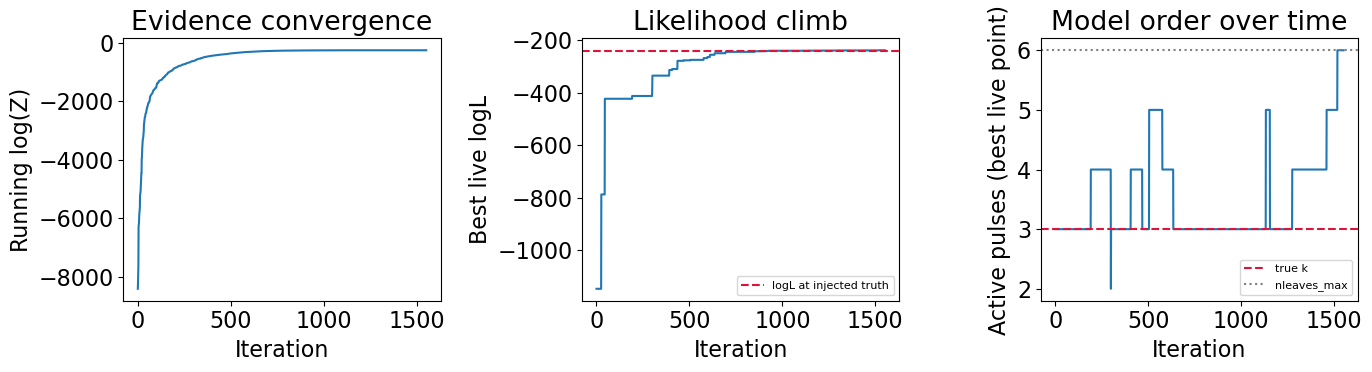

In [26]:
# SECTION 9 - FULL SAMPLER LOOP WITH STOPPING CRITERION

# 9.1 - Loop configuration
mcmc_steps_per_replacement = 20 * pulse_ndim
maximum_allowed_iterations = 6000
evidence_convergence_tolerance = 1e-3
log_evidence_convergence_tolerance = np.log(evidence_convergence_tolerance)

# 9.2 - Running evidence bookkeeping (monitoring only)
if 'running_log_evidence_estimate' not in locals():
    running_log_evidence_estimate = -np.inf
    running_log_remaining_prior_volume = 0.0
    iteration_count_completed = 0
    log_evidence_history = []
    best_live_logL_history = []
    active_pulse_count_of_best_point_history = []
    print("Initialized running evidence bookkeeping.")
else:
    print(f"Resuming from iteration {iteration_count_completed}, "
          f"running_log_evidence_estimate = {running_log_evidence_estimate:.4f}")


# 9.3 - Numerically stable log(exp(a) + exp(b))

# Standard log-sum-exp trick. We need this because the evidence Z is a sum
# of many tiny likelihood-weighted volumes, and adding them directly in
# linear space would underflow to zero almost immediately. Working in log
# space avoids that, but log(exp(a) + exp(b)) still needs care: we factor
# out the larger of the two exponents before exponentiating, so we never
# feed np.exp() a huge negative number that just becomes 0, or worse.
def log_add_exp(log_a, log_b):
    if log_a == -np.inf:
        return log_b
    if log_b == -np.inf:
        return log_a
    max_val = max(log_a, log_b)
    return max_val + np.log(np.exp(log_a - max_val) + np.exp(log_b - max_val))


# 9.4 - Main Nested Sampling loop

loop_terminated_cleanly = False
termination_reason = "reached maximum_allowed_iterations"
log_remaining_contribution_ratio = np.nan

for _ in trange(maximum_allowed_iterations, desc="Nested Sampling"):

    # Ask the inner Eryn engine to discard the worst live point and replace
    # it with a fresh one drawn from the constrained prior (logL > threshold)
    try:
        discarded_logL, replacement_logL = perform_one_nested_sampling_iteration(
            mcmc_steps_per_replacement=mcmc_steps_per_replacement)
    except RuntimeError as sampling_failure:
        termination_reason = f"live population collapsed -- {sampling_failure}"
        print(f"\nSTOPPED EARLY at iteration {iteration_count_completed}: {sampling_failure}")
        break

    iteration_count_completed += 1

    # Step B: shrink the estimated remaining prior volume.
    # Each discarded point removes roughly a fraction 1/live_points of the
    # remaining volume, so the total shrinks geometrically, iteration after
    # iteration. We track this multiplicatively, but in log space it's just
    # a running sum of log(live_points / (live_points + 1)).
    running_log_remaining_prior_volume += np.log(number_of_live_points / (number_of_live_points + 1))

    # Step C: accumulate this dead point's evidence contribution.
    # Each dead point contributes a "slice" of evidence: its likelihood
    # times the shrinking prior volume it represents, divided evenly among
    # the live points. We add this slice onto the running total using the
    # numerically safe log_add_exp from 9.3.
    log_weight_this_point = (discarded_logL
                             + running_log_remaining_prior_volume
                             - np.log(number_of_live_points))
    running_log_evidence_estimate = log_add_exp(running_log_evidence_estimate,
                                                log_weight_this_point)

    # Step D: diagnostics.
    # We keep an eye on the best point currently alive, its true physical
    # log-likelihood, and how many pulses it currently has active -- this
    # is what lets us watch the model order "settle" over time in 9.7.
    best_live_logL = live_point_true_log_likelihood.max()
    best_live_index = int(live_point_true_log_likelihood.argmax())
    active_pulse_count_of_best_point = live_point_active_leaf_mask["gauss"][0, best_live_index].sum()

    log_evidence_history.append(running_log_evidence_estimate)
    best_live_logL_history.append(best_live_logL)
    active_pulse_count_of_best_point_history.append(active_pulse_count_of_best_point)

    # Step E: stopping criterion, evaluated entirely in log space.
    # We stop once the BEST CASE remaining contribution (as if every bit of
    # remaining prior volume were as likely as our current best live point)
    # becomes negligible compared to what we've already accumulated. Doing
    # this comparison in log space matters: the difference between the two
    # logL values can be in the thousands of nats, and exponentiating that
    # directly would overflow to inf, making the comparison meaningless.
    log_max_remaining_contribution = best_live_logL + running_log_remaining_prior_volume
    log_remaining_contribution_ratio = (log_max_remaining_contribution
                                        - running_log_evidence_estimate)

    if log_remaining_contribution_ratio < log_evidence_convergence_tolerance:
        loop_terminated_cleanly = True
        termination_reason = "evidence convergence criterion satisfied"
        print(f"\nConverged at iteration {iteration_count_completed}: "
              f"log(remaining/accumulated) = {log_remaining_contribution_ratio:.3f} "
              f"< log(tol) = {log_evidence_convergence_tolerance:.3f}")
        break


# 9.5 - Post-loop summary

print(f"\n{'='*62}")
print(f"Termination reason:    {termination_reason}")
print(f"Converged cleanly:     {loop_terminated_cleanly}")
print(f"Iterations completed:  {iteration_count_completed}")
print(f"Dead points collected: {dead_point_coordinates.shape[0]}")
print(f"\nReplacements drawn by Eryn RJ-MCMC: {replacement_by_eryn_count}")
print(f"Replacements from clone fallback:   {replacement_by_clone_fallback_count}")
if replacement_by_eryn_count > 0:
    fallback_fraction = replacement_by_clone_fallback_count / (
        replacement_by_eryn_count + replacement_by_clone_fallback_count)
    print(f"Fallback fraction: {fallback_fraction:.1%}"
          f"{'  <-- ACCEPTABLE' if fallback_fraction < 0.02 else '  <-- TOO HIGH, logZ is biased'}")
print(f"\nlog Z (k>=1 model, crude estimator): {running_log_evidence_estimate:.4f}")
print(f"log Z (k=0 no-signal, analytic):     {log_evidence_no_signal_model:.4f}")
print(f"log Bayes factor signal vs noise:    "
      f"{running_log_evidence_estimate - log_evidence_no_signal_model:.4f}")
print(f"{'='*62}")


# 9.6 - Model-order histogram across ALL dead points

# This is just a raw tally: for every dead point we ever discarded, how many
# active pulses did it have? It gives a quick visual sense of where most of
# the sampler's exploration ended up, but it is NOT yet the posterior on k --
# that requires weighting each dead point by its nested sampling contribution,
# which is done properly in Section 10.
dead_point_model_order = dead_point_active_leaf_mask.sum(axis=-1).astype(int)
model_order_counts = np.bincount(dead_point_model_order, minlength=nleaves_max["gauss"] + 1)

print("\nModel-order counts among ALL dead points (raw, UNWEIGHTED):")
for k_value, count in enumerate(model_order_counts):
    marker = "  <-- TRUE" if k_value == true_number_of_pulses else ""
    if k_value == nleaves_max["gauss"] and count > 0.1 * model_order_counts.sum():
        marker += "   [CEILING SATURATED -- raise nleaves_max]"
    print(f"  k = {k_value:2d}: {count}{marker}")
print("\nNOTE: these are raw counts, NOT the posterior on k. The posterior requires "
      "the nested sampling weights and is computed in Section 10.")


# 9.7 - Diagnostic plots

# Three side-by-side views of how the run behaved:
#   left   - is the evidence estimate settling down to a stable number?
#   middle - is the best live likelihood climbing toward the true injected value?
#   right  - is the sampler converging on the true number of active pulses?
log_likelihood_at_injected_truth = true_gaussian_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis,
    observed_data, noise_standard_deviation)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(log_evidence_history)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Running log(Z)")
axes[0].set_title("Evidence convergence")

axes[1].plot(best_live_logL_history)
axes[1].axhline(log_likelihood_at_injected_truth, color="crimson", linestyle="--",
                label="logL at injected truth")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Best live logL")
axes[1].set_title("Likelihood climb"); axes[1].legend(fontsize=8)

axes[2].plot(active_pulse_count_of_best_point_history)
axes[2].axhline(true_number_of_pulses, color="crimson", linestyle="--", label="true k")
axes[2].axhline(nleaves_max["gauss"], color="grey", linestyle=":", label="nleaves_max")
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("Active pulses (best live point)")
axes[2].set_title("Model order over time"); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Section 10 — Evidence, Trace Plots, and the Posterior on the Number of Pulses

This is the payoff section: we turn the raw dead-point archive into the three things a thesis chapter on Bayesian model selection needs — the evidence (with uncertainty), the posterior over model order $k$, and the posterior over the continuous pulse parameters.

### 10.1 — Why we must "finalize" the live points before computing anything

When the Section 9 loop stops (whether by convergence or early termination), **the live population still holds a nontrivial fraction of the remaining prior mass** — that's the entire meaning of the stopping criterion ("remaining contribution is now *small*," not *zero*). If we only used the dead-point archive, we would be **discarding real evidence weight and biasing $\log\mathcal{Z}$ low**.

The standard fix (see Skilling's own reference implementation you were given — the "Begin optional final correction" block) is to treat the surviving live points as one **final batch of dead points**, each carrying its own already-known birth threshold and true log-likelihood.

### 10.2 — Why we DON'T need to hand-compute the weights anymore

Recall from Section 8 that we've been faithfully recording `birth_log_likelihood` for every single point — the constraint threshold active *when that point was born*. This was exactly future-proofing for this moment: **`anesthetic` can reconstruct the entire live-point-count history, and therefore the correct nested-sampling weights, purely from the sequence of `(logL, logL_birth)` pairs** — it doesn't need us to tell it `nlive` at all, which matters here because our `nlive` effectively fluctuates near the end (points consumed by the clone fallback subtly change the "true" information content, even though the count stays formally constant). Handing `anesthetic` the raw birth contours is strictly more correct than our own running trapezoidal estimator from Section 9 (which was explicitly a monitoring tool, never the final answer).

### 10.3 — Why the "parameter" we hand `anesthetic` is just $k$ (model order)

`anesthetic.NestedSamples` expects a fixed-dimensionality parameter table — but our problem is **trans-dimensional by construction**. Rather than force an artificial fixed-length encoding, we give `anesthetic` the ONE scalar quantity that is well-defined at every point regardless of $k$: the **number of active pulses**. This is precisely the quantity our whole thesis question hinges on, so it is not a compromise — it's the right primary column.

The continuous pulse parameters (amplitude, mean position) are handled **separately** in 10.5: we flatten every ACTIVE leaf across every point into one long table, each row inheriting its parent point's nested-sampling weight. This is the standard approach for trans-dimensional posteriors (it's exactly how the corner plot in the Eryn RJMCMC paper — "2D posterior densities for the parameters of the $k$ Gaussian peaks" — was built).

### 10.4 — Combining with the analytic $k=0$ evidence

Everything computed via Nested Sampling so far is $\mathcal{Z}_{k\geq1}$ — the evidence conditional on **at least one pulse being present** (recall `nleaves_min["gauss"]=1`, Section 5). The total model-averaged evidence is:

$$
\mathcal{Z}_{\text{total}} = \mathcal{Z}_{k=0} + \mathcal{Z}_{k\geq1}
$$

and the full posterior over $k$ — **including** $k=0$ — requires rescaling the *conditional* $k\geq1$ posterior weights by $\mathcal{Z}_{k\geq1}/\mathcal{Z}_{\text{total}}$, while $P(k=0) = \mathcal{Z}_{k=0}/\mathcal{Z}_{\text{total}}$ directly. Skipping this rescaling is a common and serious mistake — it would silently treat "no signal" and "some signal" as if they carried equal prior evidence weight, when in fact one is a single point-evidence and the other is an integral over a whole population of live/dead points.

Finalized archive: 1557 dead points + 50 finalized live points = 1607 total.
log Z (k>=1, signal present):  -262.431 +/- 0.664
Information H:                  20.087 nats
log Z (k=0, no signal, analytic): -1608.956

log Z (total, marginalizing over k=0 and k>=1): -262.431
log Bayes factor  log(Z_signal / Z_noise):       1346.526
  (>0 favors 'signal present'; this problem was built with 3 injected pulses at moderate SNR, so a strongly positive value here is the expected, healthy outcome)

Full posterior P(k | data), including k=0:
  P(k= 0) = 0.0000
  P(k= 1) = 0.0000
  P(k= 2) = 0.0000
  P(k= 3) = 0.6094  <-- TRUE
  P(k= 4) = 0.3457
  P(k= 5) = 0.0449
  P(k= 6) = 0.0000

MAP estimate of number of pulses: k = 3 (true value: 3)


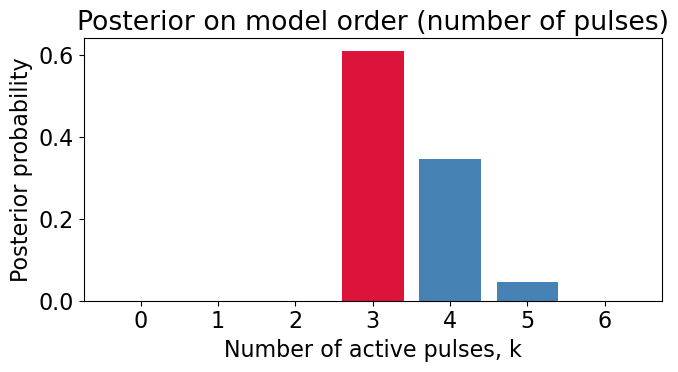


Flattened 5499 individual pulse samples for parameter-posterior plotting.


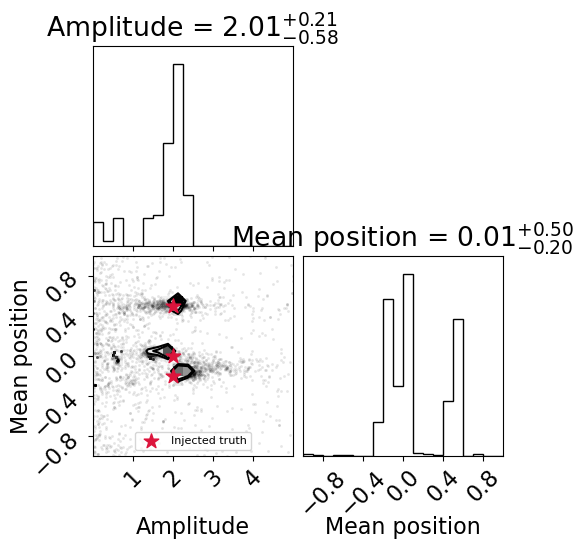

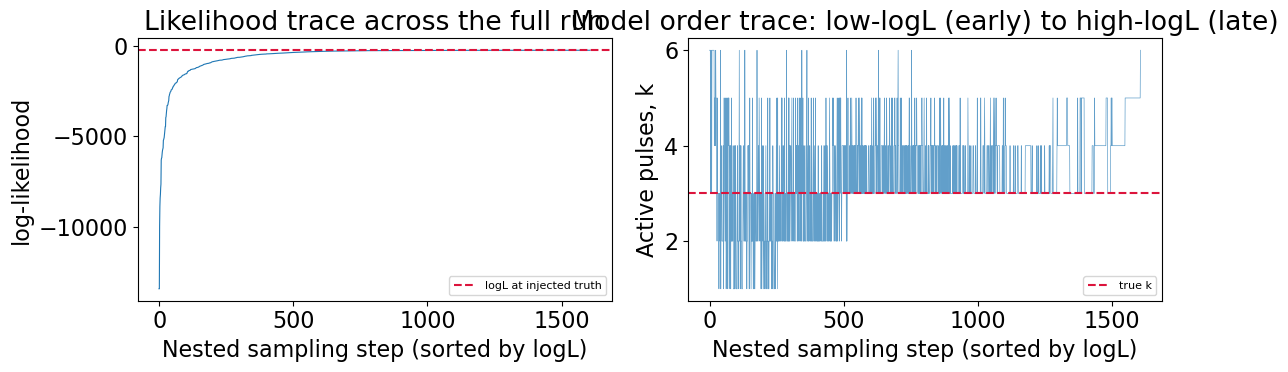


Interpretation guide for the trace plots:
- Left panel: should rise roughly monotonically and PLATEAU near the true logL.
- Right panel: should show k WANDERING BROADLY at low logL (early, unconstrained)
  and CONVERGING toward the true k at high logL (late, tightly constrained) --
  this progression is the visual signature of successful trans-dimensional
  Nested Sampling: the model order is being genuinely LEARNED, not assumed.


In [28]:
# SECTION 10 - POST-PROCESSING: EVIDENCE, TRACE PLOTS, POSTERIOR ON k

try:
    from anesthetic import NestedSamples
except ImportError:
    raise ImportError(
        "anesthetic is not installed in this environment. Run:\n"
        "    pip install anesthetic\n"
        "then restart the kernel and re-run from Section 1."
    )

# 10.1 - Finalize: fold remaining live points into the archive

# The live points still carry real evidence weight, they represent the
# innermost, not-yet-fully-explored region of prior volume. We append them
# to the SAME table as the dead points, using their true logL and their
# already-recorded birth logL, exactly like Skilling's "final correction".

final_all_coordinates = np.concatenate(
    [dead_point_coordinates, live_point_coordinates["gauss"][0]], axis=0
)
final_all_active_leaf_mask = np.concatenate(
    [dead_point_active_leaf_mask, live_point_active_leaf_mask["gauss"][0]], axis=0
)
final_all_log_likelihood = np.concatenate(
    [dead_point_log_likelihood, live_point_true_log_likelihood], axis=0
)
final_all_birth_log_likelihood = np.concatenate(
    [dead_point_birth_log_likelihood, live_point_birth_log_likelihood], axis=0
)

number_of_points_total = final_all_log_likelihood.shape[0]
print(f"Finalized archive: {dead_point_coordinates.shape[0]} dead points + "
      f"{number_of_live_points} finalized live points = {number_of_points_total} total.")

# Sanity check: birth logL must never exceed the point's own logL (a point
# cannot be born ABOVE its own likelihood, this catches bookkeeping errors)
assert np.all(final_all_birth_log_likelihood <= final_all_log_likelihood + 1e-8), \
    "Found a point whose birth threshold exceeds its own logL -- bookkeeping bug."


# 10.2 - Build the anesthetic NestedSamples table

# "data" column = model order k (the well-defined, fixed-dimensionality
# quantity across a trans-dimensional parameter space). anesthetic infers
# the ENTIRE nlive history directly from (logL, logL_birth) pairs, which is
# why we tracked birth likelihoods so carefully all the way from Section 8.

model_order_per_point = final_all_active_leaf_mask.sum(axis=-1).astype(float)

nested_samples = NestedSamples(
    data=model_order_per_point[:, None],
    logL=final_all_log_likelihood,
    logL_birth=final_all_birth_log_likelihood,
    columns=["k"]
)

# 10.3 - Evidence: mean, uncertainty, and the Bayes factor vs. k=0

log_evidence_signal_model = float(nested_samples.logZ())
information_nats = float(nested_samples.D_KL())   # anesthetic 2.0 renamed D() -> D_KL()

log_evidence_bootstrap_draws = nested_samples.logZ(nsamples=1000)

# nested_samples.logZ(nsamples=...) returns an anesthetic WeightedSeries,
# not a plain ndarray. np.std() on it dispatches to anesthetic's own weighted
# .std() implementation, which in some anesthetic versions doesn't accept the
# internal kwargs (e.g. dtype=) that NumPy passes through, hence a TypeError.
# Converting to a plain array first sidesteps that entirely.
log_evidence_bootstrap_draws_array = np.asarray(log_evidence_bootstrap_draws)
log_evidence_signal_std = float(np.std(log_evidence_bootstrap_draws_array))

print(f"log Z (k>=1, signal present):  {log_evidence_signal_model:.3f} +/- {log_evidence_signal_std:.3f}")
print(f"Information H:                  {information_nats:.3f} nats")
print(f"log Z (k=0, no signal, analytic): {log_evidence_no_signal_model:.3f}")

log_evidence_total = log_add_exp(log_evidence_signal_model, log_evidence_no_signal_model)
log_bayes_factor_signal_vs_noise = log_evidence_signal_model - log_evidence_no_signal_model

print(f"\nlog Z (total, marginalizing over k=0 and k>=1): {log_evidence_total:.3f}")
print(f"log Bayes factor  log(Z_signal / Z_noise):       {log_bayes_factor_signal_vs_noise:.3f}")
print(f"  (>0 favors 'signal present'; this problem was built with "
      f"{true_number_of_pulses} injected pulses at moderate SNR, so a strongly "
      f"positive value here is the expected, healthy outcome)")


# 10.4 - Full posterior over k, including k=0

# nested_samples' own weights are normalized to sum to 1 WITHIN the k>=1
# model. To get the true joint posterior over k (including k=0) we rescale:
#   P(k=0)   = Z_noise / Z_total
#   P(k>=1)  = [conditional weight of that k] * (Z_signal / Z_total)

posterior_weights = nested_samples.get_weights()

# Sanity check: anesthetic's returned weights must align 1:1, in the SAME row
# order, with final_all_coordinates / model_order_per_point -- everything
# downstream (10.4 and 10.5) indexes posterior_weights positionally against
# those arrays, so a silent reordering here would corrupt both the k-posterior
# and the parameter corner plot without ever raising an exception.
assert len(posterior_weights) == number_of_points_total, \
    "posterior_weights length mismatch -- anesthetic row order assumption violated."

posterior_weights = posterior_weights / posterior_weights.sum()   # normalize defensively

signal_model_posterior_mass = np.exp(log_evidence_signal_model - log_evidence_total)
no_signal_posterior_mass = np.exp(log_evidence_no_signal_model - log_evidence_total)

k_values_full_range = np.arange(0, nleaves_max["gauss"] + 1)
posterior_probability_per_k = np.zeros_like(k_values_full_range, dtype=float)
posterior_probability_per_k[0] = no_signal_posterior_mass

for k_value in range(1, nleaves_max["gauss"] + 1):
    conditional_mass_this_k = posterior_weights[model_order_per_point == k_value].sum()
    posterior_probability_per_k[k_value] = conditional_mass_this_k * signal_model_posterior_mass

assert np.isclose(posterior_probability_per_k.sum(), 1.0, atol=1e-6), \
    f"Full posterior over k does not sum to 1 (got {posterior_probability_per_k.sum():.6f})"

print("\nFull posterior P(k | data), including k=0:")
for k_value, probability in zip(k_values_full_range, posterior_probability_per_k):
    marker = "  <-- TRUE" if k_value == true_number_of_pulses else ""
    print(f"  P(k={k_value:2d}) = {probability:.4f}{marker}")

map_k_estimate = int(k_values_full_range[np.argmax(posterior_probability_per_k)])
print(f"\nMAP estimate of number of pulses: k = {map_k_estimate} "
      f"(true value: {true_number_of_pulses})")

plt.figure(figsize=(7, 4))
bar_colors = ["crimson" if k == true_number_of_pulses else "steelblue" for k in k_values_full_range]
plt.bar(k_values_full_range, posterior_probability_per_k, color=bar_colors)
plt.xlabel("Number of active pulses, k")
plt.ylabel("Posterior probability")
plt.title("Posterior on model order (number of pulses)")
plt.xticks(k_values_full_range)
plt.tight_layout()
plt.show()


# 10.5 - Posterior on the continuous pulse parameters

# Flatten every ACTIVE leaf across every point into one table, each row
# inheriting its PARENT point's nested-sampling weight. This is the standard
# way to visualize trans-dimensional posteriors (matches the corner-plot
# approach used for the analogous 2D problem in the Eryn RJMCMC paper).

flattened_active_parameters = []
flattened_parameter_weights = []

for point_index in range(number_of_points_total):
    active_mask_this_point = final_all_active_leaf_mask[point_index]
    active_params_this_point = final_all_coordinates[point_index][active_mask_this_point]
    n_active_this_point = active_params_this_point.shape[0]

    if n_active_this_point == 0:
        continue

    flattened_active_parameters.append(active_params_this_point)
    # Each of this point's leaves inherits the point's FULL weight (each leaf
    # is a separate "detected pulse" in the model, not a fractional one)
    flattened_parameter_weights.append(
        np.full(n_active_this_point, posterior_weights[point_index])
    )

flattened_active_parameters = np.concatenate(flattened_active_parameters, axis=0)
flattened_parameter_weights = np.concatenate(flattened_parameter_weights, axis=0)
flattened_parameter_weights = flattened_parameter_weights / flattened_parameter_weights.sum()

print(f"\nFlattened {flattened_active_parameters.shape[0]} individual pulse samples "
      f"for parameter-posterior plotting.")

corner_figure = corner.corner(
    flattened_active_parameters,
    weights=flattened_parameter_weights,
    labels=["Amplitude", "Mean position"],
    truths=None,   # can't mark a single "truth", there are multiple true pulses, added below
    show_titles=True,
)

# Overlay the TRUE injected pulses as red markers on the 2D panel
corner_axes = np.array(corner_figure.axes).reshape((2, 2))
scatter_ax = corner_axes[1, 0]
true_params_array = np.asarray(true_injected_pulse_parameters)
scatter_ax.scatter(true_params_array[:, 0], true_params_array[:, 1],
                   color="crimson", marker="*", s=120, zorder=10, label="Injected truth")
scatter_ax.legend(fontsize=8)
plt.show()


# 10.6 - Trace plots across the Nested Sampling sequence

# Sorting by logL recovers the actual NS sequence (dead points were archived
# in increasing-logL order; the appended live points are NOT pre-sorted, so
# we sort everything together for a clean trace).

sort_order_by_logL = np.argsort(final_all_log_likelihood)
sorted_logL = final_all_log_likelihood[sort_order_by_logL]
sorted_model_order = model_order_per_point[sort_order_by_logL]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sorted_logL, lw=0.8)
axes[0].axhline(log_likelihood_at_injected_truth, color="crimson", linestyle="--",
                label="logL at injected truth")
axes[0].set_xlabel("Nested sampling step (sorted by logL)")
axes[0].set_ylabel("log-likelihood")
axes[0].set_title("Likelihood trace across the full run")
axes[0].legend(fontsize=8)

axes[1].plot(sorted_model_order, lw=0.5, alpha=0.7)
axes[1].axhline(true_number_of_pulses, color="crimson", linestyle="--", label="true k")
axes[1].set_xlabel("Nested sampling step (sorted by logL)")
axes[1].set_ylabel("Active pulses, k")
axes[1].set_title("Model order trace: low-logL (early) to high-logL (late)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nInterpretation guide for the trace plots:")
print("- Left panel: should rise roughly monotonically and PLATEAU near the true logL.")
print("- Right panel: should show k WANDERING BROADLY at low logL (early, unconstrained)")
print("  and CONVERGING toward the true k at high logL (late, tightly constrained) --")
print("  this progression is the visual signature of successful trans-dimensional")
print("  Nested Sampling: the model order is being genuinely LEARNED, not assumed.")